# **Reduction Pipeline**

In this notebook, we continually update the srcs DataFrame, which includes each M71 observed source name, the matching synthetic spectrum index, and "status", which indicates if the spectrum is usable. After each reduction step, we update the status column to reflect the results. After all reductions, we saved the reduced spectra locally to a HDF5 file.

In [1]:
import os
import random
from pathlib import Path
import sys

#standard scientific libraries
import numpy as  np
from astropy.io import fits
import pandas as pd

#plotting
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.patches as patches
import matplotlib as mpl

#timing
from tqdm import tqdm

#jwst pipeline
import pypeit
from pypeit.metadata import PypeItMetaData
from pypeit.spectrographs.util import load_spectrograph
from pypeit import spec2dobj, specobjs

#scipy and sklearn
from sklearn.preprocessing import MinMaxScaler
from scipy.interpolate import interp1d
from scipy.ndimage import median_filter

# Custom imports
sys.path.append('SCRIPTS/')
import rest_frame_correct as rfc
import spectra as sp
from plot_1d import plot_pypeit_spec1d


In [2]:
#matplotlib params
plt.rcParams.update({
    "figure.figsize": (8, 5),  # Default figure size
    "axes.titlesize": 16,      # Title font size
    "axes.labelsize": 14,      # Axis label font size
    "xtick.labelsize": 12,     # X-tick label font size
    "ytick.labelsize": 12,     # Y-tick label font size
    "legend.fontsize": 12,     # Legend font size
    "lines.linewidth": 2,      # Line width
    "grid.alpha": 0.5,         # Grid transparency
    "grid.linestyle": "--",    # Grid line style
    "axes.grid": True,         # Show grid
    "axes.facecolor": "#F6F5F3", # Axes background color
    "savefig.dpi": 300,        # Default DPI for saving figures
    "text.usetex": True,       # Use LaTeX for text rendering
    "font.family": "serif",    # Use serif fonts
})

cs = ["#335c67","#fff3b0","#e09f3e","#9e2a2b","#540b0e", "#b3b3cc"] # Color palette for plots


In [3]:
## Paths ##
LOCAL_DATA_DIR = Path('/geir_data/scr/nwolfish/GIT_FOLDER/StarCLIP/DATA/')
PLOT_DIR = Path('/geir_data/scr/nwolfish/GIT_FOLDER/StarCLIP/FIGURES/')
PLOT_DIR.mkdir(exist_ok = True) # Create the directory if it doesn't exist

## **1. Load Data**

In [58]:
## Load in JWST files ## 
m71_catalog = pd.read_csv(LOCAL_DATA_DIR / 'CATALOGS/m71_catalog_final_matches.csv') #m71 catalog with matches to closest synthetic spectrum


synth_spec_file = LOCAL_DATA_DIR / 'LABELS/JWST_APOGEE_expanded.h5' #JWST synthetic spectra and labels file
synth_wave = pd.read_hdf(synth_spec_file, 'wavelength').values.flatten() #wavelength array for JWST synthetic spectra
synth_labels = pd.read_hdf(synth_spec_file, 'labels') #labels for JWST synthetic spectra
synth_spectra = pd.read_hdf(synth_spec_file, 'spectra') #spectra for JWST synthetic spectra, in the same order as the labels dataframe

#take all synth_labels as float
synth_labels = synth_labels.astype('float')

## reset indices
synth_spectra.reset_index(drop = True, inplace=True)
synth_labels.reset_index(drop=False, inplace=True)

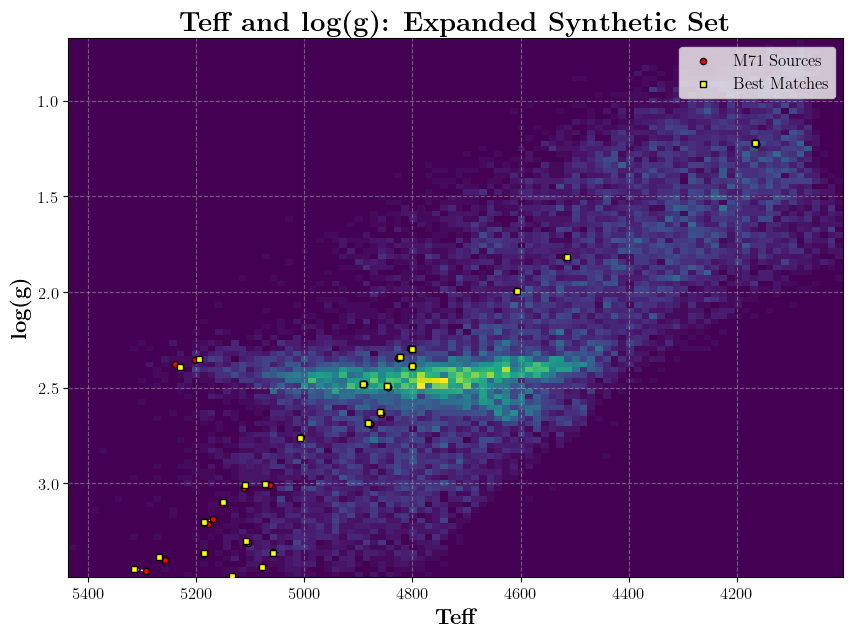

In [5]:
#kiel diagram of the expanded synthetic set, with M71 sources and best matches highlighted
fig, ax = plt.subplots(figsize = (10, 7))

#synthic 2d hist
plt.hist2d(synth_labels['Teff'], synth_labels['logg'], bins = 100, zorder = 0)
#actual m71 sources and their best matches
ax.scatter(m71_catalog['Teff_interp'], m71_catalog['logg_interp'], c = 'red', edgecolors = 'black', s = 20, label = 'M71 Sources', zorder = 40)
ax.scatter(synth_labels.loc[m71_catalog['synth_match_idx'], 'Teff'], synth_labels.loc[m71_catalog['synth_match_idx'], 'logg'], c = 'yellow', edgecolors = 'black', s = 20, marker = 's', label = 'Best Matches', zorder = 50)


for i in range(len(m71_catalog)): #plot lines connecting each M71 source to its best match
    ax.plot([m71_catalog['Teff_interp'].iloc[i], synth_labels.loc[m71_catalog['synth_match_idx'].iloc[i], 'Teff']], 
            [m71_catalog['logg_interp'].iloc[i], synth_labels.loc[m71_catalog['synth_match_idx'].iloc[i], 'logg']], 
            c = 'white', linestyle = '--', linewidth = 1, zorder = 30)
ax.legend()
ax.set_xlabel(r'\textbf{Teff}', fontsize = 16)
ax.set_ylabel(r'\textbf{log(g)}', fontsize = 16)
ax.set_title(r'\textbf{Teff and log(g): Expanded Synthetic Set}', fontsize = 20)
ax.invert_yaxis()
ax.invert_xaxis()

plt.savefig(PLOT_DIR / 'jwst_expanded_kiel_diagram.png', bbox_inches = 'tight')
plt.show()

### **Data Re-Org**

In [40]:
## Create a dataframe to hold the M71 sources, their corresponding JWST source IDs, and the indices of their best matching synthetic spectra ##
srcs = pd.DataFrame(m71_catalog['source_id'].values, columns=['source_id']) # df of m71 sources
srcs['jwst_srcs'] = [m71_catalog.loc[idx, 'source_id'] for idx in m71_catalog.index] #jwst source ids
srcs['synth_idx'] = [m71_catalog.loc[idx, 'synth_match_idx'] for idx in m71_catalog.index] # indices of best matching synthetic spectra
srcs['status'] = True # Add a status column to track which sources are successfully processed

#double for both exposures
srcs['exp'] = 2
srcs = pd.concat([srcs, srcs], ignore_index=True) #double the dataframe to have one row for each exposure
srcs.loc[srcs.index[len(srcs)//2:], 'exp'] = 3 # Set the 'exp' column to 3 for the second half of the dataframe (the duplicated rows)

In [41]:
real_spec_path = LOCAL_DATA_DIR / 'M71_SPECTRA/' #path to 1d spectra for M71 sources

#naming convention
fname = 'spec1d_jw02609006001_03101_0000{}_source_2609_{}.fits' #format with exp, source id 
spec_dfs = [] #list to hold dataframes of real spectra for each source and exposure
spec_objs = []
#save as hdf
for i in range(len(srcs)):
    src = srcs.iloc[i]['source_id']
    exp = srcs.iloc[i]['exp']
    spec_file = real_spec_path / fname.format(exp, src)
    synth_idx = srcs.iloc[i]['synth_idx']
    try:
        sobjs = specobjs.SpecObjs.from_fitsfile(spec_file) #load in spec1d file as specobjs object
        if len(sobjs) == 1: #only one source in the slit, so we can proceed
            spec_df = pd.DataFrame({
                'wavelength': sobjs['OPT_WAVE'][sobjs['OPT_MASK']],
                'flux': sobjs['OPT_COUNTS'][sobjs['OPT_MASK']],
                'uncertainty': sobjs['OPT_COUNTS_SIG'][sobjs['OPT_MASK']]
            })
            spec_objs.append(sp.Spectra(sobjs['OPT_WAVE'][sobjs['OPT_MASK']],
                                        sobjs['OPT_COUNTS'][sobjs['OPT_MASK']],
                                        sobjs['OPT_COUNTS_SIG'][sobjs['OPT_MASK']],
                                        synth_wave,
                                        synth_spectra.iloc[synth_idx].values
                                        ))
            spec_dfs.append(spec_df)
        else: 
            srcs.loc[(srcs['source_id'] == src) & (srcs['exp'] == exp), 'status'] = False #update status to False for this source
    except Exception as e: 
        print(f"Could not load spectrum for source {src}. Skipping.")
        srcs.loc[(srcs['source_id'] == src) & (srcs['exp'] == exp), 'status'] = False #update status to False for this source
        continue


[ERROR]   :: /geir_data/scr/nwolfish/GIT_FOLDER/StarCLIP/DATA/M71_SPECTRA/spec1d_jw02609006001_03101_00002_source_2609_9.fits does not exist!


Could not load spectrum for source 9. Skipping.



[ERROR]   :: /geir_data/scr/nwolfish/GIT_FOLDER/StarCLIP/DATA/M71_SPECTRA/spec1d_jw02609006001_03101_00002_source_2609_190.fits does not exist!


Could not load spectrum for source 190. Skipping.



[ERROR]   :: /geir_data/scr/nwolfish/GIT_FOLDER/StarCLIP/DATA/M71_SPECTRA/spec1d_jw02609006001_03101_00002_source_2609_2481.fits does not exist!

[ERROR]   :: /geir_data/scr/nwolfish/GIT_FOLDER/StarCLIP/DATA/M71_SPECTRA/spec1d_jw02609006001_03101_00003_source_2609_9.fits does not exist!


Could not load spectrum for source 2481. Skipping.
Could not load spectrum for source 9. Skipping.



[ERROR]   :: /geir_data/scr/nwolfish/GIT_FOLDER/StarCLIP/DATA/M71_SPECTRA/spec1d_jw02609006001_03101_00003_source_2609_190.fits does not exist!


Could not load spectrum for source 190. Skipping.
Could not load spectrum for source 2481. Skipping.



[ERROR]   :: /geir_data/scr/nwolfish/GIT_FOLDER/StarCLIP/DATA/M71_SPECTRA/spec1d_jw02609006001_03101_00003_source_2609_2481.fits does not exist!


In [42]:
# once saved, drop non-True statuses from srcs dataframe to have a clean list of sources with successfully loaded spectra
srcs = srcs[srcs['status'] == True].reset_index(drop=True)

## **Normalize Real Spectra**

In [43]:
# normalize
for spec in spec_objs:
    real_spec_scaler = MinMaxScaler()
    spec.spectrum = real_spec_scaler.fit_transform(spec.spectrum.reshape(-1, 1)).flatten() 

## **Doppler Shift**

In [44]:
wl_lims = [(13000, 13250), (14000, 14250), (14900, 15150)] #spectral features to fit to 

for i, spec in tqdm(enumerate(spec_objs), total=len(spec_objs)): #loop through spectra and apply rest frame correction
    best_rv = rfc.rest_frame_correction(spec.wavelength, spec.synth_wavelength, spec.spectrum, spec.synth_spectrum, spec.uncertainty, central_rv = -22.9, wl_lims = wl_lims, plot=False, prev_range = 50) #best rv in km/s, should be around -22.9 km/s for M71

    #apply shift to wl
    if best_rv is not None:
        spec.wavelength = rfc.doppler_shift(spec.wavelength, best_rv) # apply Doppler shift with best RV
    
    # select spectral ranges to fit to for each source, standardize accross sources (mask out non fit wl ranges)
    srcs.loc[i, 'best_rv'] = best_rv #save best rv to srcs dataframe for later analysis

100%|██████████| 59/59 [01:39<00:00,  1.68s/it]


In [49]:
mean_rv = np.mean(srcs['best_rv'])
std_rv = np.std(srcs['best_rv'])

# sources more than 1 std dev from the mean, or with NaN RVs
mask_outlier = (np.abs(srcs['best_rv'] - mean_rv) > 1*std_rv) | (np.isnan(srcs['best_rv']))
outliers = srcs[mask_outlier]
srcs['status'] &= ~srcs.index.isin(outliers.index) # update status to False for outliers, keep True for non-outliers
print(f"Mean RV: {mean_rv:.2f} km/s, Std Dev: {std_rv:.2f} km/s")

Mean RV: -16.50 km/s, Std Dev: 67.08 km/s


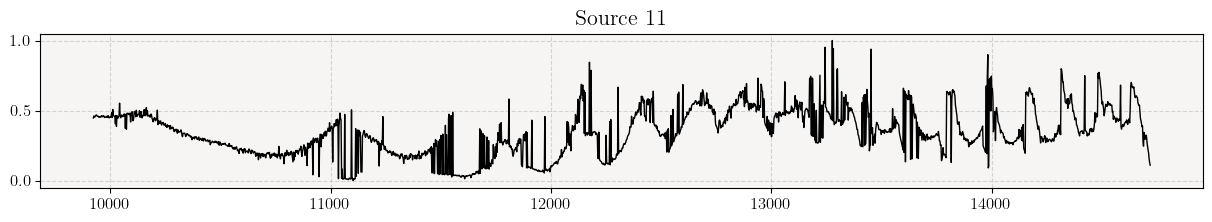

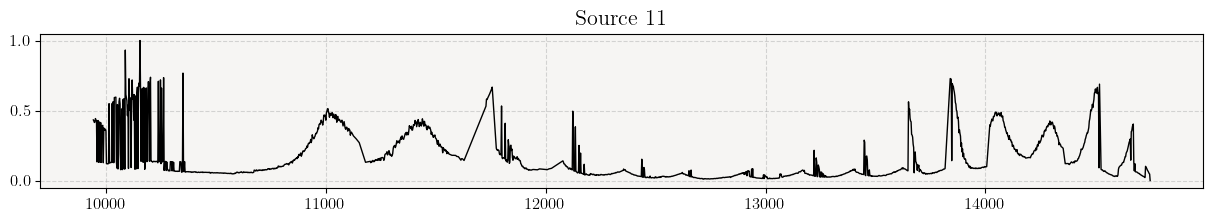

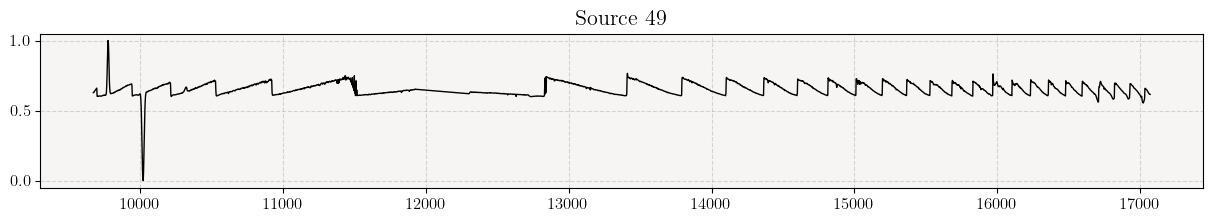

In [57]:
#plot to make sure the outliers are actually bad fits and not just weird but good fits
for src in outliers.index:
    plt.figure(figsize = (15, 2))
    plt.plot(spec_objs[src].wavelength, spec_objs[src].spectrum, label = 'Real Spectrum', linewidth = 1, color = 'k')
    plt.title(f"Source {srcs.loc[src, 'source_id']}", fontsize = 16)

## **Continuum Fitting**

In [52]:
## Save the successfully loaded spectra to an HDF5 file, using the source IDs and exposure numbers in the keys ##
status_true = srcs[srcs['status'] == True]
spec_dfs_passed = [spec_dfs[i] for i in status_true.index] #only keep spectra for sources with True status


assert len(status_true) == len(spec_dfs_passed), "Number of successfully loaded spectra does not match number of True statuses!"
with pd.HDFStore(LOCAL_DATA_DIR / 'LABELS/M71_SPECTRA.h5', 'w') as store:
    for i, df in enumerate(spec_dfs_passed):
        exp = status_true.iloc[i]['exp']
        src = status_true.iloc[i]['source_id']
        key = f'SPEC_exp{exp}_src{src}'
        store.put(key, df)